# **Exploring the Results of Pipeline Statistical Decisions**

# Import Libraries and Configurations

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import pandas as pd

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..', '..')))

from config import (
    DATA_SUBDIRS,
    EXPRESSION_FILES,
    NETWORK_DATA_DIRS,
    NETWORK_FILES,
    TCGA_DATA_DIRS,
)

# Data Loading

In [2]:
# Initialize dictionaries to store the DataFrame of interest
correlations = dict()
mir_expressions = dict()
rna_expressions = dict()

# Iterate over each study group
for subdir in DATA_SUBDIRS:
    # DataFrame of inferred interactions
    dir_path = NETWORK_DATA_DIRS['processed'][subdir]
    file_name = NETWORK_FILES['inferred-interactions']
    correlations[subdir] = pd.read_csv(os.path.join(dir_path, file_name))

    # DataFrame of aggregated raw microRNA read counts
    dir_path = TCGA_DATA_DIRS['processed'][subdir]
    file_name = EXPRESSION_FILES['agg-mirs-raw-reads']
    mir_expressions[subdir] = pd.read_csv(os.path.join(dir_path, file_name))

    # DataFrame of aggregated raw messenger RNA read counts
    dir_path = TCGA_DATA_DIRS['processed'][subdir]
    file_name = EXPRESSION_FILES['agg-mrnas-raw-reads']
    rna_expressions[subdir] = pd.read_csv(os.path.join(dir_path, file_name))

# Basal-like

## Correlation and Q-value

In [3]:
# Statistical description of correlation values
correlations['basal-like'][['correlation']].describe()

,correlation
count,41169.000000
mean,-0.009094
std,0.144543
min,-0.563990
25%,-0.106765
50%,-0.009951
75%,0.086334
max,0.777265


array([[<Axes: title={'center': 'correlation'}>]], dtype=object)

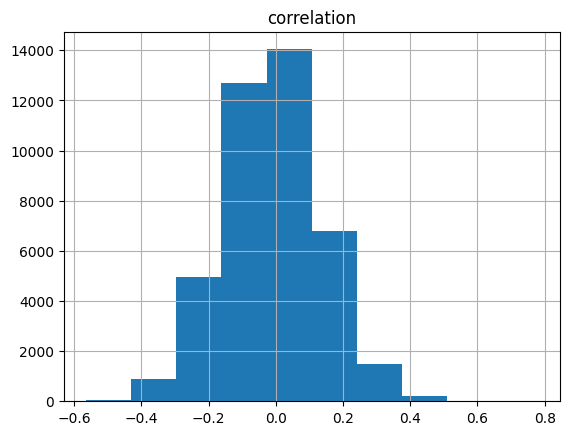

In [4]:
# Histogram plot of correlation values
correlations['basal-like'][['correlation']].hist()

array([[<Axes: title={'center': 'qvalue'}>]], dtype=object)

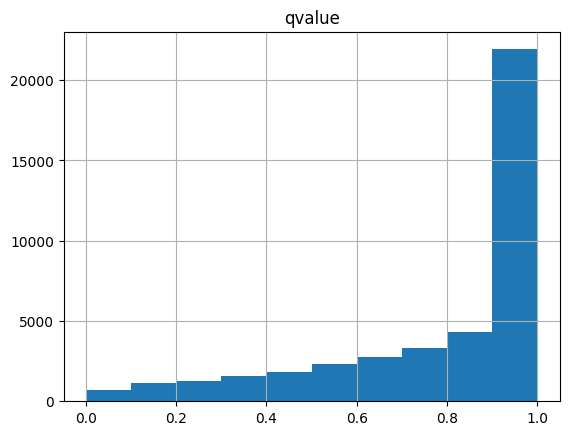

In [5]:
# Histogram plot of q-value values
correlations['basal-like'][['qvalue']].hist()

## Aggregated Expressions

In [6]:
# Sum the read counts of all samples by microRNA
df_sum = mir_expressions['basal-like'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 1:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 1:], axis=1)

# Order the total read counts of the expressed microRNAs
df_sum \
    .query('is_expressed == 1') \
    [['accession_id', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,accession_id,total_reads,non_zero_samples
0,MIMAT0001541,160,20
1,MIMAT0019841,254,59
2,MIMAT0018443,281,48
3,MIMAT0003331,333,75
4,MIMAT0019850,388,75
...,...,...,...
431,MIMAT0000259,8230013,89
432,MIMAT0000689,9195581,89
433,MIMAT0000077,12236160,89
434,MIMAT0000243,13798337,89


In [7]:
# Sum the read counts of all samples by messenger RNA
df_sum = rna_expressions['basal-like'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 2:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 2:], axis=1)

# Order the total read counts of the expressed messenger RNAs
df_sum \
    .query('is_expressed == 1') \
    [['gene_name', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,gene_name,total_reads,non_zero_samples
0,CST9L,20,9
1,PRLH,23,10
2,KLHL1,31,15
3,STH,33,25
4,G6PC2,35,17
...,...,...,...
16901,MT-CO2,27582177,89
16902,EEF1A1,29367639,89
16903,ACTB,35438265,89
16904,MT-CO1,47847702,89


# HER2-enriched

## Correlation and Q-value

In [8]:
# Statistical description of correlation values
correlations['her2-enriched'][['correlation']].describe()

,correlation
count,41169.000000
mean,-0.022086
std,0.156822
min,-0.587491
25%,-0.130554
50%,-0.024675
75%,0.082228
max,0.792309


array([[<Axes: title={'center': 'correlation'}>]], dtype=object)

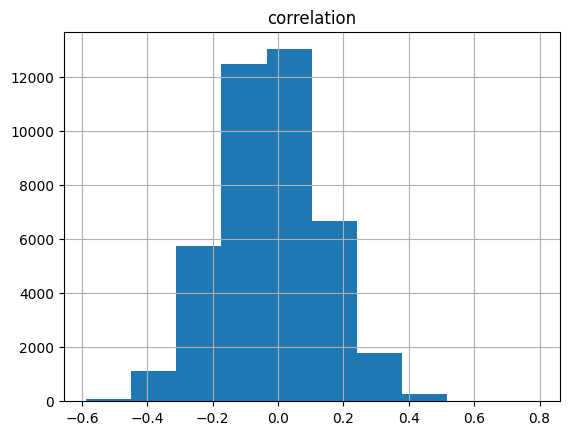

In [9]:
# Histogram plot of correlation values
correlations['her2-enriched'][['correlation']].hist()

array([[<Axes: title={'center': 'qvalue'}>]], dtype=object)

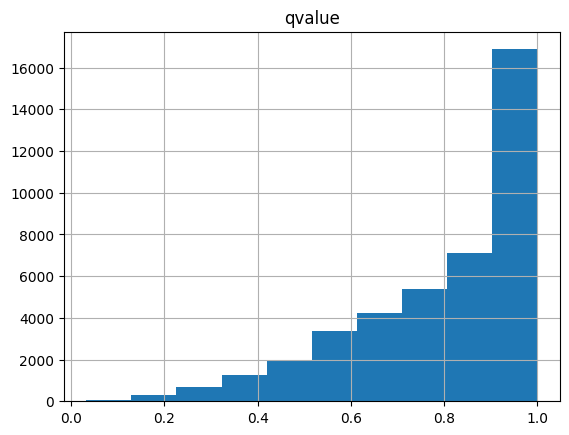

In [10]:
# Histogram plot of q-value values
correlations['her2-enriched'][['qvalue']].hist()

In [11]:
# Order interactions of interest based on correlation values
correlations['her2-enriched'] \
    .query('is_interaction_of_interest == 1') \
    .sort_values(by='correlation', ascending=True) \
    .reset_index(drop=True)

,accession_id,mirna_name,gene_name,mirtarbase,correlation,pvalue,qvalue,is_interaction_of_interest
0,MIMAT0000432,hsa-miR-141-3p,IGF2,NaN,-0.587491,9.681125e-07,0.032134,1
1,MIMAT0000065,hsa-let-7d-5p,MEF2D,MIRT735654,-0.562406,3.225376e-06,0.032134,1
2,MIMAT0000732,hsa-miR-378a-3p,ACP6,NaN,-0.561791,3.317913e-06,0.032134,1
3,MIMAT0000072,hsa-miR-18a-5p,ZBTB20,NaN,-0.558715,3.818749e-06,0.032134,1
4,MIMAT0000680,hsa-miR-106b-5p,PLXDC2,NaN,-0.558237,3.902691e-06,0.032134,1
5,MIMAT0000065,hsa-let-7d-5p,SMARCC1,NaN,-0.546275,6.649086e-06,0.041507,1
6,MIMAT0000680,hsa-miR-106b-5p,SALL1,NaN,-0.544908,7.057413e-06,0.041507,1
7,MIMAT0000065,hsa-let-7d-5p,HIF1AN,NaN,-0.539303,8.986564e-06,0.041561,1
8,MIMAT0000065,hsa-let-7d-5p,PRKAR2A,NaN,-0.536637,1.006593e-05,0.041561,1
9,MIMAT0000646,hsa-miR-155-5p,VAV3,NaN,-0.536569,1.009512e-05,0.041561,1


In [12]:
# Order interactions of interest based on correlation values
correlations['her2-enriched'] \
    .query('(correlation < -0.3) and (qvalue < 0.1)') \
    .sort_values(by='correlation', ascending=True) \
    .reset_index(drop=True)

,accession_id,mirna_name,gene_name,mirtarbase,correlation,pvalue,qvalue,is_interaction_of_interest
0,MIMAT0000432,hsa-miR-141-3p,IGF2,NaN,-0.587491,9.681125e-07,0.032134,1
1,MIMAT0000065,hsa-let-7d-5p,MEF2D,MIRT735654,-0.562406,3.225376e-06,0.032134,1
2,MIMAT0000732,hsa-miR-378a-3p,ACP6,NaN,-0.561791,3.317913e-06,0.032134,1
3,MIMAT0000072,hsa-miR-18a-5p,ZBTB20,NaN,-0.558715,3.818749e-06,0.032134,1
4,MIMAT0000680,hsa-miR-106b-5p,PLXDC2,NaN,-0.558237,3.902691e-06,0.032134,1
5,MIMAT0000065,hsa-let-7d-5p,SMARCC1,NaN,-0.546275,6.649086e-06,0.041507,1
6,MIMAT0000680,hsa-miR-106b-5p,SALL1,NaN,-0.544908,7.057413e-06,0.041507,1
7,MIMAT0000065,hsa-let-7d-5p,HIF1AN,NaN,-0.539303,8.986564e-06,0.041561,1
8,MIMAT0000065,hsa-let-7d-5p,PRKAR2A,NaN,-0.536637,1.006593e-05,0.041561,1
9,MIMAT0000646,hsa-miR-155-5p,VAV3,NaN,-0.536569,1.009512e-05,0.041561,1


## Aggregated Expressions

In [13]:
# Sum the read counts of all samples by microRNA
df_sum = mir_expressions['her2-enriched'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 1:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 1:], axis=1)

# Order the total read counts of the expressed microRNAs
df_sum \
    .query('is_expressed == 1') \
    [['accession_id', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,accession_id,total_reads,non_zero_samples
0,MIMAT0004977,80,22
1,MIMAT0000428,121,32
2,MIMAT0005452,121,28
3,MIMAT0004761,158,46
4,MIMAT0002891,184,48
...,...,...,...
431,MIMAT0000259,5285575,58
432,MIMAT0000254,6998977,58
433,MIMAT0000243,8368969,58
434,MIMAT0000077,8644238,58


In [14]:
# Sum the read counts of all samples by messenger RNA
df_sum = rna_expressions['her2-enriched'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 2:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 2:], axis=1)

# Order the total read counts of the expressed messenger RNAs
df_sum \
    .query('is_expressed == 1') \
    [['gene_name', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,gene_name,total_reads,non_zero_samples
0,GABRA4,15,11
1,NLRP13,17,12
2,SPPL2C,22,11
3,KCTD4,26,15
4,OR10A3,28,16
...,...,...,...
16901,MT-CO3,18588875,58
16902,FN1,21954794,58
16903,COL1A1,22479540,58
16904,MT-ND4,29026284,58


# Luminal A

## Correlation and Q-value

In [15]:
# Statistical description of correlation values
correlations['luminal-a'][['correlation']].describe()

,correlation
count,41169.000000
mean,-0.011423
std,0.118207
min,-0.477429
25%,-0.088814
50%,-0.015971
75%,0.058455
max,0.688844


array([[<Axes: title={'center': 'correlation'}>]], dtype=object)

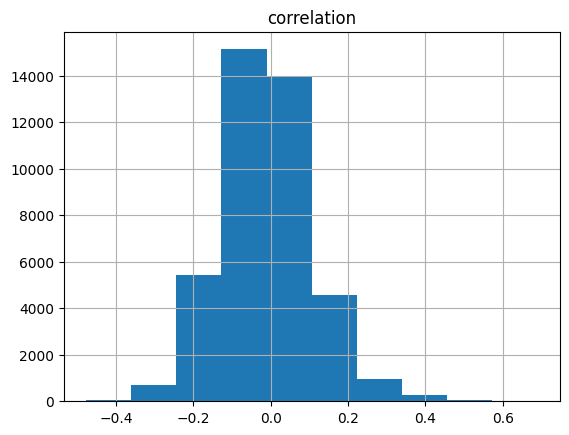

In [16]:
# Histogram plot of correlation values
correlations['luminal-a'][['correlation']].hist()

array([[<Axes: title={'center': 'qvalue'}>]], dtype=object)

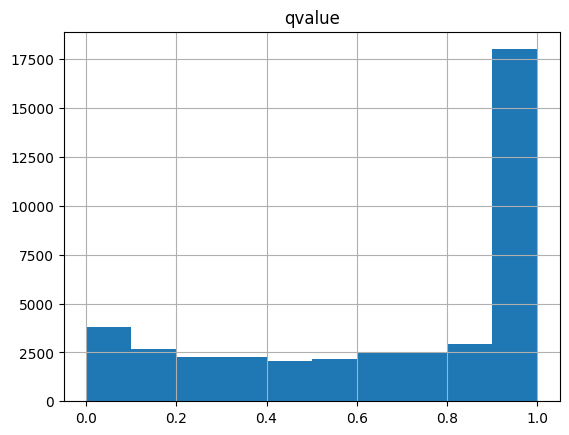

In [17]:
# Histogram plot of q-value values
correlations['luminal-a'][['qvalue']].hist()

## Aggregated Expressions

In [18]:
# Sum the read counts of all samples by microRNA
df_sum = mir_expressions['luminal-a'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 1:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 1:], axis=1)

# Order the total read counts of the expressed microRNAs
df_sum \
    .query('is_expressed == 1') \
    [['accession_id', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,accession_id,total_reads,non_zero_samples
0,MIMAT0004977,108,55
1,MIMAT0002891,325,138
2,MIMAT0030017,515,133
3,MIMAT0004949,534,162
4,MIMAT0009198,597,168
...,...,...,...
431,MIMAT0000259,28131723,225
432,MIMAT0000077,36734463,225
433,MIMAT0000087,42202050,225
434,MIMAT0000254,48269825,225


In [19]:
# Sum the read counts of all samples by messenger RNA
df_sum = rna_expressions['luminal-a'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 2:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 2:], axis=1)

# Order the total read counts of the expressed messenger RNAs
df_sum \
    .query('is_expressed == 1') \
    [['gene_name', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,gene_name,total_reads,non_zero_samples
0,FAM240A,149,64
1,ACOD1,233,95
2,KCNA4,239,103
3,OR10A3,251,94
4,KCNV1,270,67
...,...,...,...
16901,COL3A1,77070147,225
16902,COL1A2,86729361,225
16903,MT-ND4,102899363,225
16904,COL1A1,113626772,225


# Luminal B

## Correlation and Q-value

In [20]:
# Statistical description of correlation values
correlations['luminal-b'][['correlation']].describe()

,correlation
count,41169.000000
mean,-0.025650
std,0.130270
min,-0.493395
25%,-0.114541
50%,-0.028488
75%,0.059379
max,0.645325


array([[<Axes: title={'center': 'correlation'}>]], dtype=object)

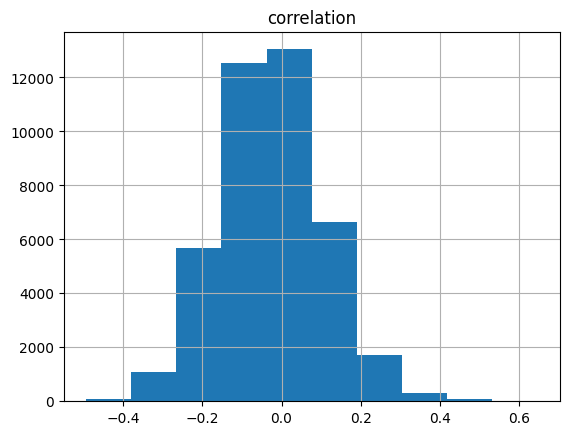

In [21]:
# Histogram plot of correlation values
correlations['luminal-b'][['correlation']].hist()

array([[<Axes: title={'center': 'qvalue'}>]], dtype=object)

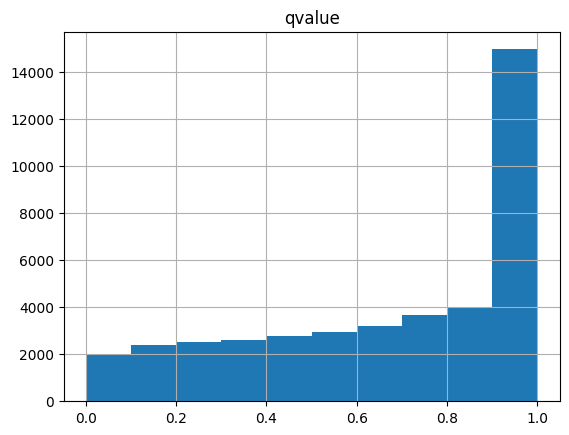

In [22]:
# Histogram plot of q-value values
correlations['luminal-b'][['qvalue']].hist()

## Aggregated Expressions

In [23]:
# Sum the read counts of all samples by microRNA
df_sum = mir_expressions['luminal-b'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 1:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 1:], axis=1)

# Order the total read counts of the expressed microRNAs
df_sum \
    .query('is_expressed == 1') \
    [['accession_id', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,accession_id,total_reads,non_zero_samples
0,MIMAT0004977,30,18
1,MIMAT0005452,244,48
2,MIMAT0002891,253,91
3,MIMAT0009198,255,82
4,MIMAT0004504,346,98
...,...,...,...
431,MIMAT0000259,11285462,122
432,MIMAT0000254,13973195,122
433,MIMAT0000077,14011546,122
434,MIMAT0000087,15596510,122


In [24]:
# Sum the read counts of all samples by messenger RNA
df_sum = rna_expressions['luminal-b'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 2:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 2:], axis=1)

# Order the total read counts of the expressed messenger RNAs
df_sum \
    .query('is_expressed == 1') \
    [['gene_name', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,gene_name,total_reads,non_zero_samples
0,LALBA,33,18
1,FAM240A,35,21
2,CAPZA3,56,31
3,OR10A3,65,24
4,TLX3,69,17
...,...,...,...
16901,MT-CO3,36297117,122
16902,FN1,38846987,122
16903,COL1A1,41187954,122
16904,MT-ND4,56581552,122


# Normal

## Correlation and Q-value

In [25]:
# Statistical description of correlation values
correlations['normal'][['correlation']].describe()

,correlation
count,41169.000000
mean,-0.014032
std,0.272012
min,-0.815995
25%,-0.210253
50%,-0.019754
75%,0.174299
max,0.874163


array([[<Axes: title={'center': 'correlation'}>]], dtype=object)

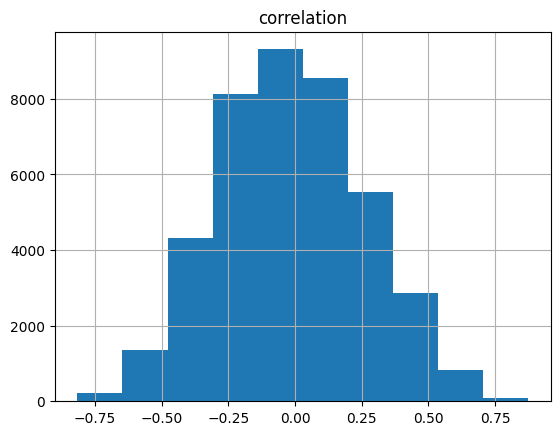

In [26]:
# Histogram plot of correlation values
correlations['normal'][['correlation']].hist()

array([[<Axes: title={'center': 'qvalue'}>]], dtype=object)

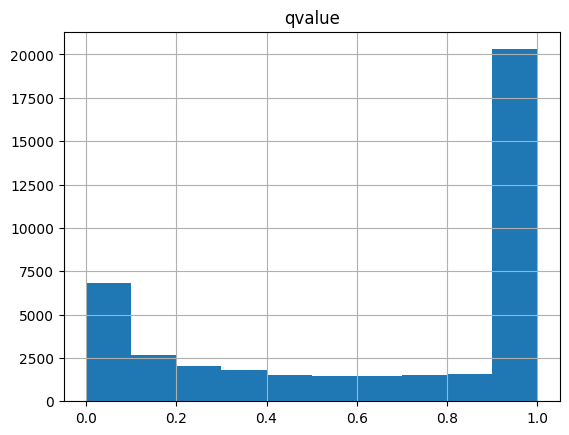

In [27]:
# Histogram plot of q-value values
correlations['normal'][['qvalue']].hist()

In [28]:
# Order interactions of interest based on correlation values
correlations['normal'] \
    .query('is_interaction_of_interest == 1') \
    .sort_values(by='correlation', ascending=True) \
    .reset_index(drop=True)

,accession_id,mirna_name,gene_name,mirtarbase,correlation,pvalue,qvalue,is_interaction_of_interest
0,MIMAT0000077,hsa-miR-22-3p,RPS3,NaN,-0.815995,9.198691e-15,3.787009e-10,1
1,MIMAT0001635,hsa-miR-452-5p,RPA1,NaN,-0.809911,2.036391e-14,3.923583e-10,1
2,MIMAT0000432,hsa-miR-141-3p,TRHDE,NaN,-0.807245,2.859129e-14,3.923583e-10,1
3,MIMAT0000077,hsa-miR-22-3p,RPL14,NaN,-0.804375,4.096492e-14,4.216212e-10,1
4,MIMAT0000077,hsa-miR-22-3p,LRRC1,MIRT030660,-0.800410,6.666675e-14,5.308921e-10,1
...,...,...,...,...,...,...,...,...
5067,MIMAT0000093,hsa-miR-93-5p,USP37,NaN,-0.332468,6.148441e-03,4.991622e-02,1
5068,MIMAT0000250,hsa-miR-139-5p,ZC3H12A,NaN,-0.332468,6.148441e-03,4.991622e-02,1
5069,MIMAT0000093,hsa-miR-93-5p,CREBRF,MIRT028082,-0.332468,6.148441e-03,4.991622e-02,1
5070,MIMAT0000068,hsa-miR-15a-5p,PHF21A,NaN,-0.332468,6.148441e-03,4.991622e-02,1


In [29]:
# Order interactions of interest based on correlation values
correlations['normal'] \
    .query('(correlation < -0.3) and (qvalue < 0.1)') \
    .sort_values(by='correlation', ascending=True) \
    .reset_index(drop=True)

,accession_id,mirna_name,gene_name,mirtarbase,correlation,pvalue,qvalue,is_interaction_of_interest
0,MIMAT0000077,hsa-miR-22-3p,RPS3,NaN,-0.815995,9.198691e-15,3.787009e-10,1
1,MIMAT0001635,hsa-miR-452-5p,RPA1,NaN,-0.809911,2.036391e-14,3.923583e-10,1
2,MIMAT0000432,hsa-miR-141-3p,TRHDE,NaN,-0.807245,2.859129e-14,3.923583e-10,1
3,MIMAT0000077,hsa-miR-22-3p,RPL14,NaN,-0.804375,4.096492e-14,4.216212e-10,1
4,MIMAT0000077,hsa-miR-22-3p,LRRC1,MIRT030660,-0.800410,6.666675e-14,5.308921e-10,1
...,...,...,...,...,...,...,...,...
6248,MIMAT0000103,hsa-miR-106a-5p,ARL1,NaN,-0.300137,1.230560e-02,8.105751e-02,0
6249,MIMAT0004697,hsa-miR-151a-5p,SOX12,NaN,-0.300137,1.230560e-02,8.105751e-02,0
6250,MIMAT0000066,hsa-let-7e-5p,DUSP16,NaN,-0.300068,1.232275e-02,8.115747e-02,0
6251,MIMAT0003339,hsa-miR-421,CMTM4,NaN,-0.300048,1.232788e-02,8.117825e-02,0


## Aggregated Expressions

In [30]:
# Sum the read counts of all samples by microRNA
df_sum = mir_expressions['normal'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 1:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 1:], axis=1)

# Order the total read counts of the expressed microRNAs
df_sum \
    .query('is_expressed == 1') \
    [['accession_id', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,accession_id,total_reads,non_zero_samples
0,MIMAT0019841,12,10
1,MIMAT0019059,23,10
2,MIMAT0003882,27,12
3,MIMAT0003260,28,17
4,MIMAT0001541,49,17
...,...,...,...
431,MIMAT0000087,7430156,58
432,MIMAT0000076,8879322,58
433,MIMAT0000077,12085885,58
434,MIMAT0000435,16460615,58


In [31]:
# Sum the read counts of all samples by messenger RNA
df_sum = rna_expressions['normal'].copy()
df_sum['total_reads'] = df_sum.iloc[:, 2:].sum(axis=1)
df_sum['non_zero_samples'] = np.count_nonzero(df_sum.iloc[:, 2:], axis=1)

# Order the total read counts of the expressed messenger RNAs
df_sum \
    .query('is_expressed == 1') \
    [['gene_name', 'total_reads', 'non_zero_samples']] \
    .sort_values(by='total_reads', ascending=True) \
    .reset_index(drop=True)

,gene_name,total_reads,non_zero_samples
0,PRAC2,2,3
1,MAGEA12,5,5
2,CSAG1,6,7
3,IFNL3,8,8
4,IFNL2,11,8
...,...,...,...
16901,MT-CYB,18820612,58
16902,MT-CO3,19083612,58
16903,EEF1A1,24329827,58
16904,MT-ND4,31478821,58
